# <span style='font-family:"serif"'><font color='k'>Inflow with Ram Pressure Stripping</font>

In [1]:
## <span style='font-family:"serif"'><font color='k'>Inflow with Ram Pressure Stripping</font>
import numpy as np
from   scipy.special import hyp2f1, expi
import matplotlib.pyplot as plt

import plotly
import plotly.graph_objs as go

from labellines import *

from matplotlib.ticker import (AutoMinorLocator, MultipleLocator)
from matplotlib.ticker import FormatStrFormatter

## <span style='font-family:"serif"'>Main functions</font>

>### <span style='font-family:"serif"'><font color='k'> Part 1: gas--$\alpha$-abundance relations</font>

#### <span style='font-family:"serif"'> This cell contains functions to build gas-abundance relation: _eq_before_g_, _eq_after_g_abs_, _eq_after_g_equal_ build Z(g) before the forced _gas_ loss occured (Z<sub>1</sub>(g) corresponds to "Before RPS" (ram pressure stripping)), and after (for &xi; != &zeta; and &xi; == &zeta; respectively; note, that &xi; parameter I write everywhere as _F_, &zeta; parameter I write as _E_ or _Es_; Z<sub>2</sub>(g) corresponds to "After RPS"). </font>
#### <span style='font-family:"serif"'> To merge them into a single solution, the initial conditions for equation(s) "After RPS" are replaced with RPS-value obtained from parameter [&alpha;/H]<sub>str</sub> and corresponding gas fraction point obtained with function _g_rps_.</font>
#### <span style='font-family:"serif"'> _long_coef_ is a part of the expression for Z<sub>2</sub>(g) ("After RPS") with &xi; != &zeta;.</font>

#### <span style='font-family:"serif"'> _gas_equation_ combines above formulae and returns gas for equally spaced N = _points_ alpha abundances within [&alpha;/H]<sub>min</sub>=-5, [&alpha;/H]<sub>max</sub>=0</font>

#### <span style='font-family:"serif"'> There are solutions Z(g) which on g-log(Z) plot are convex. It depends on g-&xi;, g-(&xi;-&zeta;) signs: if gas is below than the normalized inflow, the function is monotonic, but if less, the ([&alpha;/H], g) plot will contain two "branches", upper, with gas decrease for &alpha;-abundance increase, and lower branch, where the gas decreases for &alpha;-abundance decrease. In this situation I chose "upper" branch, while fixation of inflow after [&alpha;/H]<sub>str</sub> for some minimal value also decreases the significance of the lower branch. Figure 1, green dashed line illustrates this point: the turning point is almost at g = 0.

In [7]:
def format_ticks(majorl=15, minorl=7, xdel=1, ydel=5):
    '''
    This function is for figure formatting
    '''
    plt.rcParams.update({'font.family': 'DeJavu Serif'})
    plt.rcParams.update({'font.serif':'Times New Roman'})
    plt.gca().tick_params(which='major', direction="in", length=majorl,\
                        labelbottom=True, labeltop=False, labelleft=True, labelright=False,
                        bottom=True, top=True, left=True, right=True)
    plt.gca().tick_params(which='minor', direction="in", length=minorl,\
                        labelbottom=True, labeltop=False, labelleft=True, labelright=False,
                        bottom=True, top=True, left=True, right=True)
    plt.gca().xaxis.set_major_locator(MultipleLocator(xdel))
    plt.gca().yaxis.set_major_locator(MultipleLocator(ydel))
    plt.gca().xaxis.set_minor_locator(AutoMinorLocator(5))
    plt.gca().yaxis.set_minor_locator(AutoMinorLocator(5))

def locin(f, func):
    
    integ = 0
    n = len(f)
    
    for i in range(n):
        if i==0 or i==n-1:
            integ += func[i]*(f[1]-f[0])/2
        else:
            integ += func[i]*(f[1]-f[0])
    
    return integ

def smooth_kernel(x, y1, dy, c='g', show=False, ax=None):
    
    '''
    Transformed from IDL (ENK) function for
    inclusion of error uncertainty 
    '''
    n = len(x)
    y2 = []
    xdiff = []
    
    for i in range(n-1):
        xdiff.append(x[i+1]-x[i])
    xdiff = np.array(xdiff)
    
    halfn = round(n/2.)
    
    halfwindow0 = round(1.1*4.*max(dy)/min(xdiff[np.where(xdiff>0.)]))
    
    if halfwindow0 < halfn:
        halfwindow = halfwindow0
    else:
        halfwindow = halfn
    
    gauss = np.zeros(n)
    gaussx = np.array(x - np.mean(x))
    
    for j in range(len(dy)):
        gauss += np.exp(-0.5*(gaussx/dy[j])**2)/dy[j]
    
    for i in range(n):
        low = (i-halfwindow) if (i-halfwindow) > 0 else 0
        high = ((i+halfwindow)-1) if ((i+halfwindow)-1) < (n-1) else (n-1)
        
        lowg  = halfn - halfwindow - (i-halfwindow - low)
        highg = halfn + halfwindow - (i+halfwindow - high)
        
        if ((low<n) and (low<high)):
            y2.append(sum(y1[low:high]*gauss[lowg:highg])/sum(gauss[lowg:highg]))
    
    y2 = np.array(y2)
    
    if ax:
        
        ax.plot(x, y1, linestyle = 'none', marker = 'o', c='c', markersize = 1.5, label='Initial')
        ax.plot(x, y2, linestyle = 'none', marker = 'o', c= c, markersize=1.5, label='Smoothed')
        ax.legend(loc = 'upper left')
        
        return ax, y2
    
    elif show:
        
        plt.plot(x, y1, linestyle = 'none', marker = 'o', c='c', markersize = 1.5, label='Initial')
        plt.plot(x, y2, linestyle = 'none', marker = 'o', c= c, markersize=1.5, label='Smoothed')
        plt.legend(loc = 'upper left')
        plt.show()
        
        return y2
        
    else:
        
        return y2


def eq_before_g(F, z_inflow, z_initial, g, g_in = 1.):
    
    '''
        Determines z' = Z/p_eff = (10^[alpha/H])/p_eff 
    for array of g using equation "Before RPS"
    (where p_eff = p/(1+eta) - effective yield)
    ------
    Input:
    ------
    F            normalized inflow, xi
    z_inflow     alpha-abundance of inflow, expressed as z'_inflow
    z_initial    initial alpha-abundance, for z'_initial
    g            array of g values
    g_in         initial fraction of gas. We assumed that galaxy has started as cloud of gas: g_in=1
    ------
    Returns:
    ------
    z            array of z' values
    '''
    
    z = np.full(len(g), -np.inf)
    
    if F!=g_in:
        i = np.where((((F-g)/(F-g_in)>0) & (g!=0.)))[0]
        z[i] = g_in*(F-g[i])/g[i]/(F-g_in)*z_initial+\
                (F-g[i])/g[i]*(np.log(((F-g[i])/(F-g_in)))) +\
               F*(g[i]-g_in)/g[i]/(F-g_in)*(z_inflow+1)
    return z

def g_rps(F, z_inflow, z_initial, z_str):
    
    '''
        Determines gas fraction in units of initial galaxies' mass
    at moment when RPS commences, associated with [alpha/H]=[alpha/H]_s.
    ------
    Input:
    ------
    F            normalized inflow, xi
    z_inflow     alpha-abundance of inflow, expressed as z'_inflow
    z_initial    initial alpha-abundance, for z'_initial
    z_str        alpha-abundance by achieving which RPS begins, z'_str
    ------
    Returns:
    ------
    g_str        gas fraction at z' = z'_str = (10^[alpha/H]_s)/p_eff
    '''
    
    g = np.linspace(0., F*1.9999, 1000)
    z = eq_before_g(F, z_inflow, z_initial, g)
    z[np.where(np.isnan(z))] = -np.inf
    delta = np.min(abs(z-z_str))
    
    if z.max()>z_str:
        g_str = g[np.where(abs(z-z_str)==delta)]
        if isinstance(g_str, list) or isinstance(g_str, np.ndarray):
            g_str = g_str[0]
    else:
        g_str = F*.9999
    
    return g_str

def long_coef(F, Es, z_inflow, z_initial, g_in=1.):
    
    '''
        Supplemental function for equation z'(g) after RPS has started.
    ------
    Input:
    ------
    F            normalized inflow, xi
    Es           normalized forced gas outflow, zeta
    z_inflow     alpha-abundance of inflow, expressed as z'_inflow
    z_initial    initial alpha-abundance, for z'_initial
    g_in         initial fraction of gas
    ------
    Returns:
    ------
    Constant term for equation z'(g) after RPS if F!=Es.
    '''
    
    return ((g_in/F+(Es-F)/F)*hyp2f1(1,1,F/(F-Es)+1, g_in/(F-Es))+(F-Es)/F+z_inflow-z_initial)


def eq_after_g_abs(F, Es, z_inflow, z_initial, long_coef, g, g_in=1.): 
    '''
       Determines z' = Z/p_eff = (10^[alpha/H])/p_eff for 
    array of g using equation "After RPS" where F != Es
    (where p_eff = p/(1+eta) - effective yield).
    ------
    Input:
    F            normalized inflow, xi
    Es           normalized forced gas outflow, zeta
    z_inflow     alpha-abundance of inflow, expressed as z'_inflow
    z_initial    initial alpha-abundance, for z'_initial
    long_coef    constant value (see long_coef() function)
    g            array of g values
    g_in         gas at beginning of RPS epoch, g_stripped
    ------
    Returns:
    z            array of z' values: len(z)=len(g)
    '''
    return -np.power(g*(g_in-F+Es)/(g_in*(g-F+Es)), F/(Es-F))*long_coef + \
            1/F*(g-F+Es)*hyp2f1(1,1,F/(F-Es)+1, g/(F-Es)) + (F-Es)/F+z_inflow
    
def eq_after_g_equal(F, z_inflow, z_initial, g, g_in):
    
    '''
       Determines z' = Z/p_eff = (10^[alpha/H])/p_eff for 
    array of g using equation "After RPS" where F = Es
    (where p_eff = p/(1+eta) - effective yield).
    ------
    Input:
    F            normalized inflow xi
    z_inflow     alpha-abundance of the inflow expressed as z'_inflow
    z_initial    initial alpha-abundance for z'_initial
    g            array of g values
    g_in         initial fraction of gas
    ------
    Returns:
    z            array of z' values: len(z)=len(g).
    '''
    
    return np.exp(-F*(1./g-1./g_in))*(z_initial-z_inflow) + \
           np.exp(-F/g)*(expi(F/g)-expi(F/g_in)) + z_inflow

def gas_equation(p_eff, F, Es, aH_str, F2 = 0.01, aH_inflow=-5., aH_initial=-5., points = 5001, ax = np.nan, show=True,\
                 labels = [True, True, True, [True, True, True, True, True]], xx = 0, c='k'):
    # Do not touch F2. Unless you really want to.
    
    '''
       Function to determine g(z').
    ------
    Input:
    ------
    p_eff        effective yield in Solar metallicity units
    F            normalized inflow, xi
    Es           normalized forced gas outflow, zeta
    aH_inflow    alpha-abundance of inflow
    aH_initial   initial alpha-abundance
    aH_str       alpha-abundance at moment when RPS begins
    points       length of returned g array
    show         show the figure of g([alpha/H])
    ------
    Returns:
    ------
    g([alpha/H])   gas as a function of alpha-abundance
    '''
    
    # Determine two z'(g) (before and after RPS) separately.
    # Then consider only parts which are required to construct final g(z')
    arr = 1000
    
    z_inflow  = (10**aH_inflow)/p_eff
    z_initial = (10**aH_initial)/p_eff
    z_str     = (10**aH_str)/p_eff
    
    # If xi<1, g will decrease with [alpha/H] for [alpha/H]<[alpha/H]_s
    if F<1:  loss = True;  g_max = 1.
    else:    loss = False; g_max = 1.9999*F
    
    g    = np.linspace(0, g_max, arr)
    
    # Initial gas g_in of equation "After RPS":
    g_str = g_rps(F, z_inflow, z_initial, z_str)

    # "After RPS" inflow xi:
    F2 =  F2 #0.01
    
    # Derive long_coef for "After RPS" equation
    if F2!=Es:
        coef_here = long_coef(F2, Es, z_inflow, z_str, g_str)
    
    # Calculate z'(g) from "Before RPS"
    z_before = eq_before_g(F, z_inflow, z_initial, g)
    
    # If xi>1, and if p_eff is very small, g achieves xi at max(z_before) << z_str,
    # which from Extreme Inflow model of Larson (1986) balances gas loss with gas inflow
    # and makes further increase of alpha-abundance impossible:
    if np.max(z_before[np.where(np.isfinite(z_before))])<z_str:
        return
    
    z_after = []
    
    # Calculate z'(g) from "After RPS".
    for i in range(len(g)):
        if F2==Es:
            z_after.append(eq_after_g_equal(F2, z_inflow, z_str, g[i], g_str))
        else:
            z_after.append(eq_after_g_abs(F2, Es, z_inflow, z_str, coef_here, g[i], g_str))
    
    z_before = np.array(z_before)
    z_after  = np.array(z_after)
    
    z_before, g_before = z_before[np.where(np.isfinite(z_before) & (z_before>0))], g[np.where(np.isfinite(z_before) & (z_before>0))]
    aH_before         = np.log10(z_before*p_eff)
    z_after,  g_after  = z_after[np.where(np.isfinite(z_after) & (z_after>0))   ], g[np.where(np.isfinite(z_after) & (z_after>0))]    
    
    # z'(g) for "After RPS" with Es>F2 is convex function.
    # On g(z') plot, let's consider it as two branches, upper and lower.
    # for upper branch  z' increases with gas decrease
    # for lower branch  z' decreases with gas decrease
    # Conditions for IRPS usage were determined to exclude that (lower) metal-poor branch:
    z_max    = z_after.max()
    z_after0 = z_after
    g_after0 = g_after
    
    g_edge = g_after[np.where(z_after==z_max)]
    
    z_after, g_after = z_after[np.where(g_after>g_edge)], g_after[np.where(g_after>g_edge)]
    aH_after        = np.log10(z_after*p_eff)
    
    # In both cases g increments. If loss==True or Es>F2, [alpha/H] will 
    # decrease. To recover order arrays must be flipped as follows
    if loss:
        aH_before, g_before = np.flip(aH_before), np.flip(g_before)
    if loss or Es>=F2:
        aH_after,  g_after  = np.flip(aH_after),  np.flip(g_after)
    
    g_f   = g_before[np.where(aH_before<=aH_str)]
    aH_f = aH_before[np.where(aH_before<=aH_str)]
    g_f   = np.append(g_f,     g_after[np.where(aH_after>aH_str)])
    aH_f = np.append(aH_f, aH_after[np.where(aH_after>aH_str)])

    legend_final = ['Parameters of\nthe IRPS model.\nGas-'+r'$\alpha$'+'-abundance laws.\n'+r'g([$\alpha$/H])'+'\nBefore RPS' if labels[0] else None,\
                   'After RPS' if labels[1] else None,\
                   '', '', '']
    if show:
        try:
            if ax==np.nan:
                fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(3.5, 2.5),
                        layout="constrained")
        except: pass
        
        ax.plot(aH_before, g_before, color='gold', linestyle='solid', lw = 2, label=legend_final[0], zorder = 0)
        ax.plot(np.log10(z_after0*p_eff), g_after0, color='orange', lw = 2, linestyle='solid', label=legend_final[1], zorder=0)
        
        ax.set_ylim([-2.5, 30.2*1.1])
        ax.set_xlim([-5., 0.])
    
    g_f, aH_f = g_f[np.where((np.isfinite(g_f) & np.isfinite(aH_f) & (aH_f<5.)))],\
               aH_f[np.where((np.isfinite(g_f) & np.isfinite(aH_f) & (aH_f<5.)))]
    
    aH_min_1 = np.min(aH_before)
    aH_max_1 = np.max(aH_after)
    
    alphah = np.linspace(-5., 0., points)
    gas = np.interp(alphah, aH_f, g_f)
    gas[np.where(alphah<aH_min_1)] = 1.
    
    if aH_max_1 < 0.:
        gas[np.where(alphah>=aH_max_1)] = 0.
    
    if show:
        
        titles = ["\u03BE"+f'={np.round(F,3)       if not labels[3][0] and F>1 else int(F)}',\
                  '\u03B6'+f'={int(np.round(Es,1)) if labels[3][1] and Es>1 else np.round(Es,2)}',\
                  r'p_{eff}'+f'={np.round(p_eff,2)}',\
                  r'[\alpha/H]_s'+f'={np.round(aH_str,1)}',\
                  "\u03BE"+r"_{s}"+f'={int(np.round(F2,0)) if (labels[3][-1] and F2>1) else np.round(F2,3)}']
        text = ''
        for index, i in enumerate(labels[3]):
            
            if not i:
                if r'_' in titles[index]:
                    br1 = ';$'
                    br2 = '$'
                else:
                    br1 = ';'
                    br2 = ''
                if index==0: br1 = ''
                if legend_final[3]!='':
                    legend_final[4] += br1 + titles[index] + br2
                else:
                    legend_final[2] += br1 + titles[index] + br2
            else:
                legend_final[3] += titles[index][:np.where(np.array(list(titles[index]))=='=')[0][0]]
                if index!=0:
                    legend_final[2] += ';'
            
            if i:
                text = titles[index][np.where(np.array(list(titles[index]))=='=')[0][0]+1:]
        
        #ax.set_title(legend_final[2]+r'$\bf{{{b}}}$'.format(b = legend_final[3])+\
        #             legend_final[4],\
        #             x=0.5, y = 0.9, bbox=dict(facecolor='white', edgecolor='none'))
        legend_final[2] = None
        ax.plot(np.linspace(-5., 0., points), gas, color = c,\
                linestyle='solid', lw = 2.4, zorder=1)
        
        if text != '':

            if labels[3][-1]:
                c='orange'
                ax.plot(np.log10(p_eff*z_after0[np.where(g_after0<g_after0[np.where(z_after0==z_max)])]),\
                        g_after0[np.where(g_after0<g_after0[np.where(z_after0==z_max)])],\
                       color='orange', zorder=-250)
            lines = ax.get_lines()
            l1=lines[-1]
            
            labelLine(l1,x=xx,label=text, color = c,\
                      zorder = 10 if  labels[3][-1] else 250, backgroundcolor='white',\
                     outline_width = 0.1, bbox=dict(facecolor='white', edgecolor='none', pad=0.), weight='bold')
        
        ax.set_xlabel(r"$[\alpha/H]$")
        ax.set_ylabel("Gas, "+r'$M_{initial}$')
            
    return gas

def a2(p, F, E,  aH_str, F2=0.01, alphah=None, gas=None, aH_f=-5., show=False,  ax=None, error=0.106, c='k', label=None):
    
    '''
       The IRPS model (which sometimes I refer as Accretion-2, A2).
    ------
    Input:
    ------
    p           effective yield in Solar metallicity units
    aH_f        alpha-abundance of inflow
    F           normalized inflow xi
    E           normalized forced gas outflow zeta'_s
    alphah      array of [alpha/H] where the alpha-abundance distribution function should be calculated
    gas         array of gas points for each [alpha/H]
    aH_str      alpha-abundance at the moment when RPS begins, aH_s
    ------
    Returns:
    ------
    r([alpha/H])    Model points.    
    '''
    
    l = None
    if isinstance(gas, float):
        gas = np.array([gas])
        alphah = np.array([alphah])
        l = 1.
        
    r = np.zeros(len(gas))
    ph1 = np.where(((gas!=0)&(alphah<=aH_str)))[0]
    ph2 = np.where(((gas!=0)&(alphah>aH_str)))[0]
    
    r[ph1] = (10**alphah[ph1])*gas[ph1]/p/(1+(10.**aH_f-10.**alphah[ph1])/p*F/gas[ph1])
    r[ph2] = (10**alphah[ph2])*gas[ph2]/p/(1+(10.**aH_f-10.**alphah[ph2])/p*F2/gas[ph2])
    
    r[np.where(r<0.)] = 0.
    if isinstance(l, float):
        r = r[0]
        show = False

    r = smooth_kernel(alphah, r, np.full(len(r), error))
    
    if show:
        try:
            if ax==np.nan:
                fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(3.5, 2.5),
                        layout="constrained")
        except: pass
        
        ax.plot(alphah, r/locin(alphah, r), c=c, ls = 'solid', lw=2.4,\
                label = label, zorder= 300 if c!='k' else 0)
        
    return r

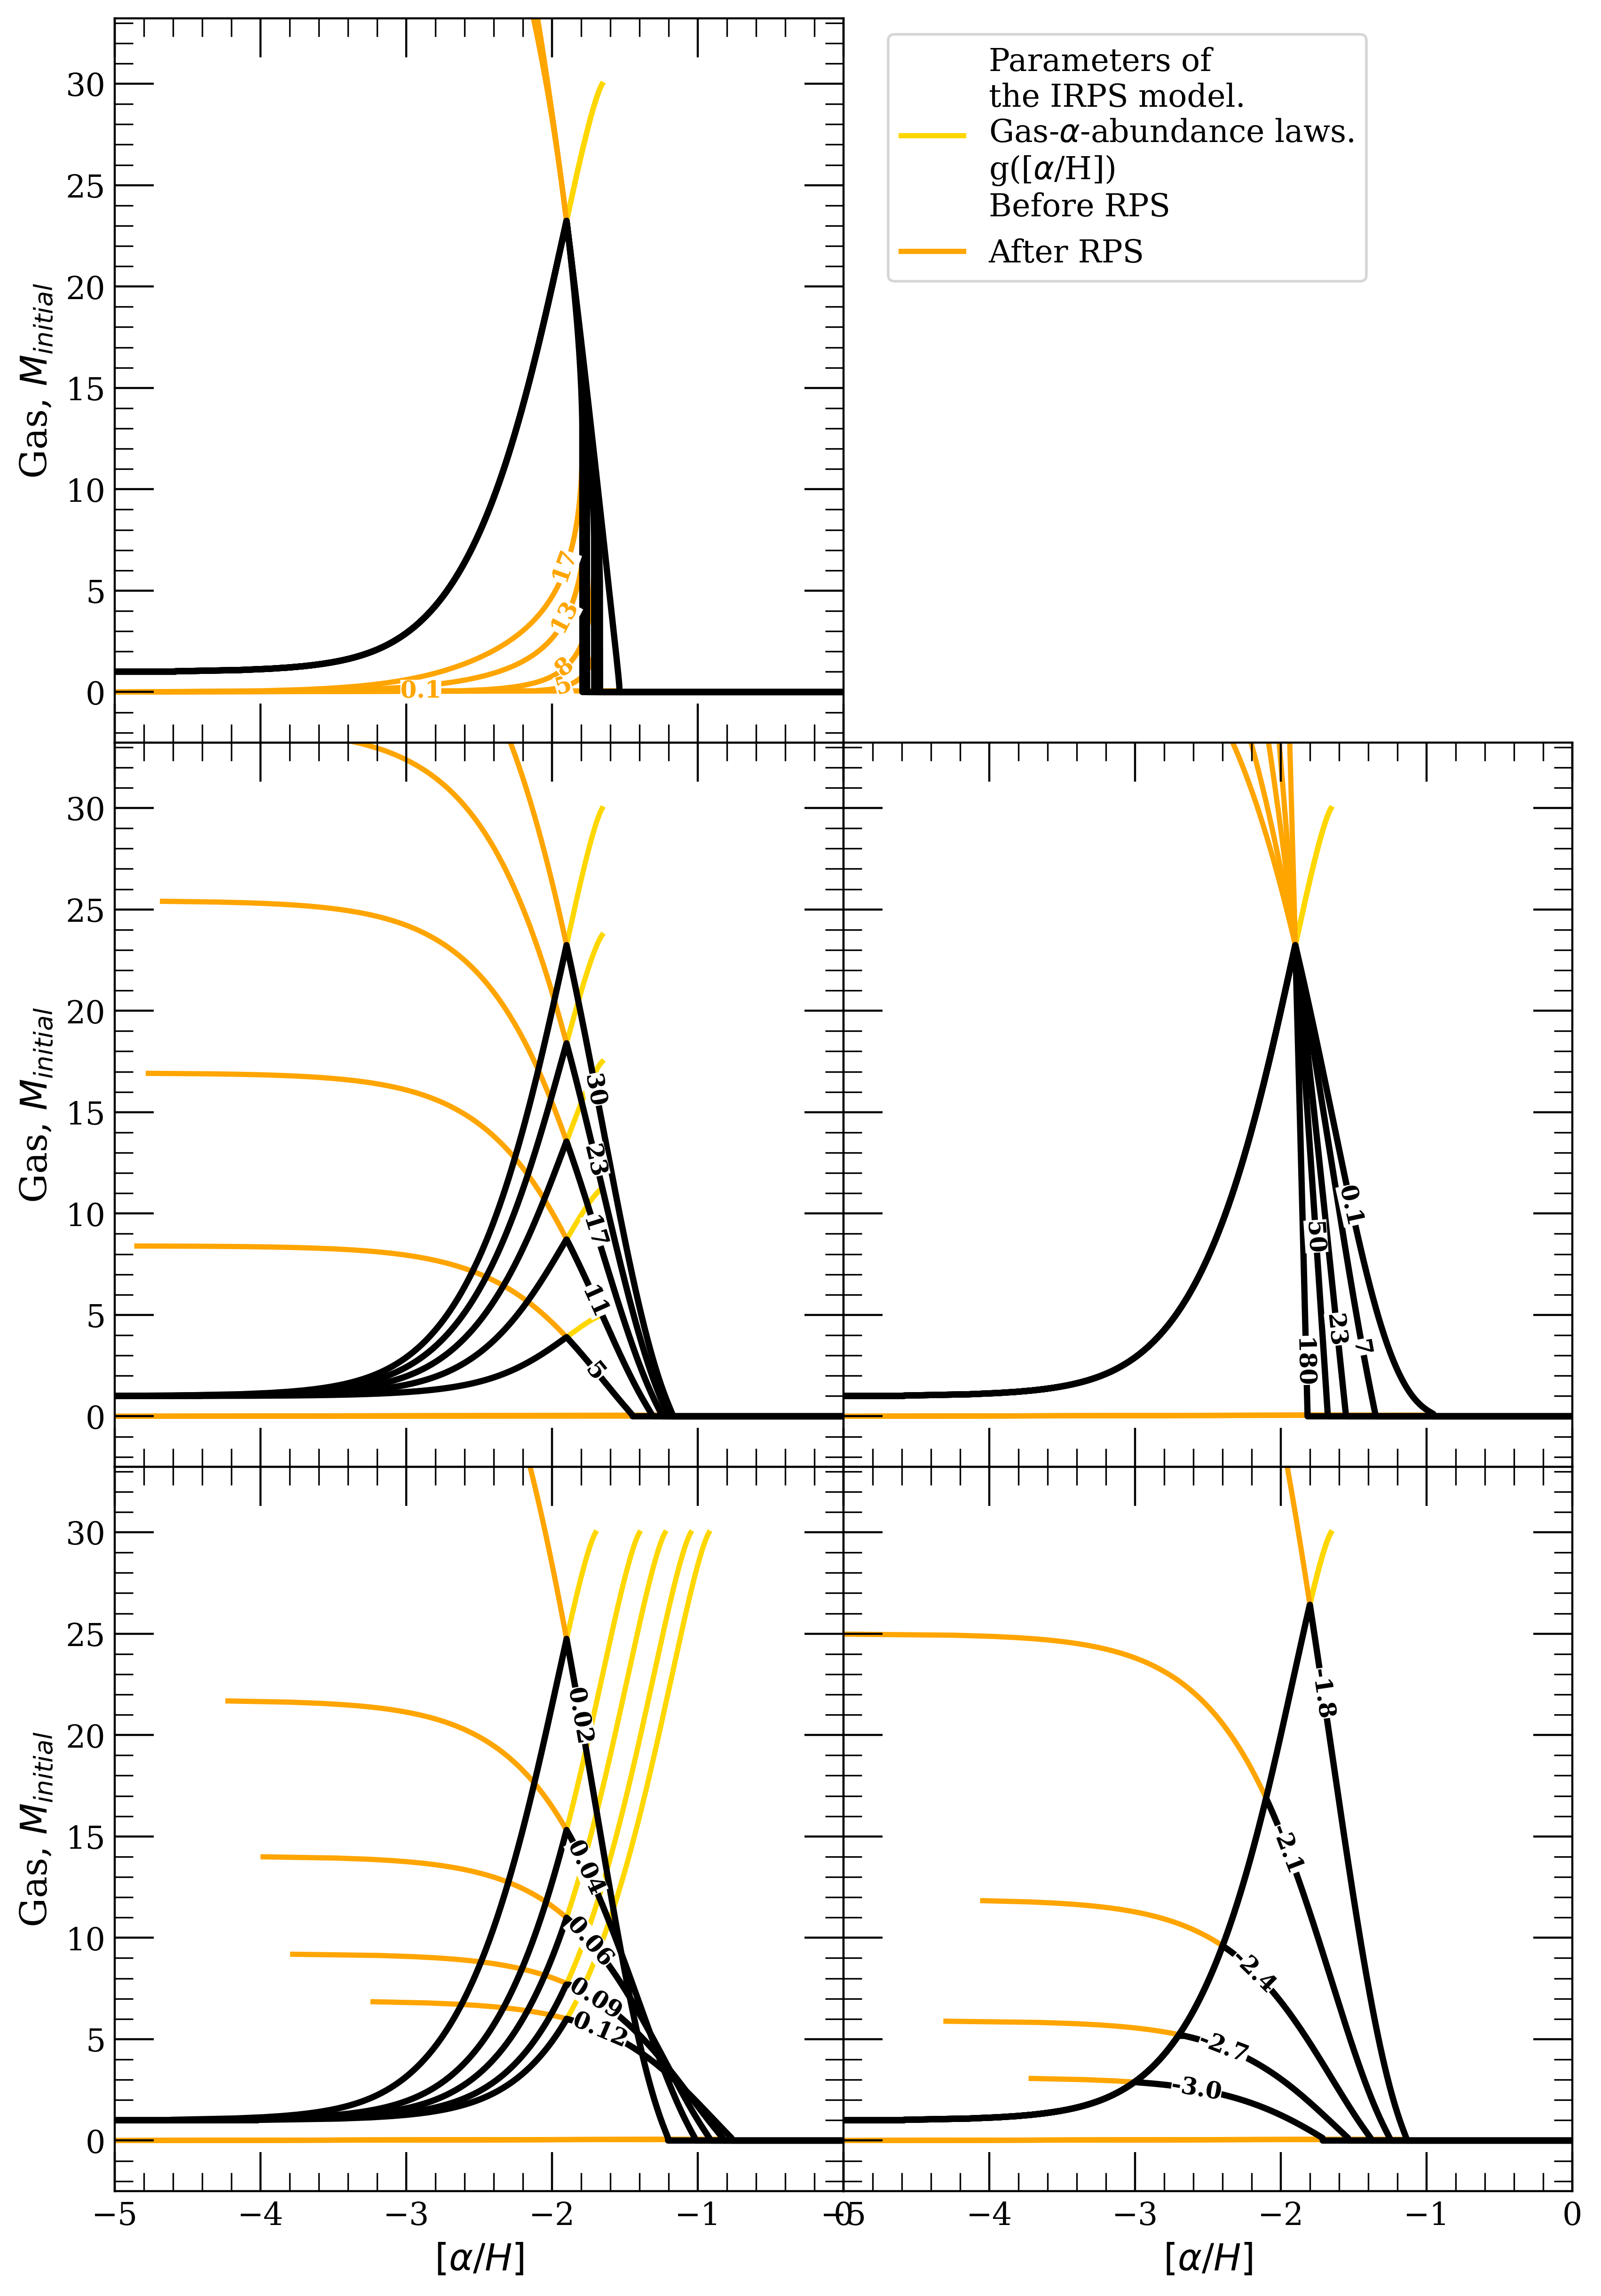

In [9]:
alphah = np.linspace(-5., 0., 5001)
p = 0.0222; F = 30; E = 2; aH_str = -1.9

fig  = plt.figure(figsize=(10,15), dpi=400)
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=9)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE-4)  # fontsize of the figure title

ax1 = fig.add_subplot(323)
format_ticks()
for index, temp in enumerate(np.linspace(5., 30, 5)):
    if index==4: labels = [False, False, True, [True, False, False, False, False]]
    else: labels = [False, False, False, [True, False, False, False, False]]
    gas2 = gas_equation(p, temp, E, aH_str, 0.01, -5, -5, points=5001, ax=ax1,\
                        show=True, labels=labels, xx=-1.7);


ax2 = fig.add_subplot(324)
format_ticks()
for index, temp in enumerate(np.array([0.1, 7., 23., 50., 180.])):
    if index == 4: labels = [False, False, True, [False, True, False, False, False]]
    else: labels = [False, False, False, [False, True, False, False, False]]
    gas2 = gas_equation(p, F, temp, aH_str, 0.01, -5, -5, points=5001, ax=ax2,\
                        show=True, labels=labels, xx=aH_str+(1/temp*(0.009 if temp==0.1 else 1.))**(0.5 if temp>25 else .4));

ax3 = fig.add_subplot(325)
format_ticks()
for index, temp in enumerate(np.array([0.02, 0.04, 0.06, 0.09, 0.12])):
    if index == 4: labels = [False, False, True, [False, False, True, False, False]]
    else: labels = [False, False, False, [False, False, True, False, False]]
    gas2 = gas_equation(temp, F, E, aH_str, 0.01, -5, -5, points=5001, ax=ax3,\
                        show=True, labels=labels, xx=aH_str+(temp)**(0.5)/1.5);

ax4 = fig.add_subplot(326)
format_ticks()
for index, temp in enumerate(np.linspace(-3., -1.8, 5)):
    if index == 4: labels = [False, False, True, [False, False, False, True, False]]
    else: labels = [False, False, False, [False, False, False, True, False]]
    gas2 = gas_equation(p, F, E, temp, 0.01, -5, -5, points=5001, ax=ax4,\
                        show=True, labels=labels, xx=temp+(abs(temp)/4.)**3);

ax5 = fig.add_subplot(321)
format_ticks()
#F = 25.1; E = 32.5; aH_str = -2.5
#for index, temp in enumerate(np.linspace(10.01, 28, 5)):
F = 30; E = 20.; aH_str = -1.9
for index, temp in enumerate([0.1, 5., 8., 13., 17.25]):
    if index==4: labels =  [True, True, True, [False, False, False, False, True]]
    else: labels = [False, False, False, [False, False, False, False, True]]
    gas2 = gas_equation(p, F, E, aH_str, temp, -5, -5, points=5001, ax=ax5,\
                        show=True, labels=labels, xx = aH_str-0.1/temp)

ax5.legend(bbox_to_anchor=(1.04, 1), loc="upper left");
for ax in [ax5, ax1, ax2]:
    ax.set_xticklabels([])
    ax.set_xlabel(None)
for ax in [ax2, ax4]:
    ax.set_yticklabels([])
    ax.set_ylabel(None)

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0, hspace=0)
#plt.savefig(f'examples_sq_v2.eps', format='eps', bbox_inches='tight', pad_inches=0)
#plt.savefig(f'examples_sq_v2.pdf', format='eps', bbox_inches='tight', pad_inches=0)
plt.show()

## 

In [ ]:
SMALL_SIZE = 14
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=10)
plt.rc('axes', titlesize=10)
plt.rc('axes', labelsize=MEDIUM_SIZE)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)
plt.rc('legend', fontsize=14)
plt.rc('figure', titlesize=10)

#cs = ['deeppink', 'dodgerblue', 'yellow', 'darkorange', 'red']
cs = ['dodgerblue', 'royalblue', 'mediumblue', 'blue', 'navy']
#cs = ['mediumvioletred','darkmagenta','purple', 'indigo', 'midnightblue']
fig  = plt.figure(figsize=(20,8), dpi=1500)

ax = list(np.full((2,5), None))

alphah = np.linspace(-5., 0., 501)
p = 0.0222; F = 30; E = 2; aH_str = -1.9
parset = {'F': (np.linspace(5., 30, 5), np.full(5,-2.15), r'$\xi$'),\
          'Es': (np.array([0.1, 7., 23., 50., 180.]), np.array([aH_str+(1/temp*(0.009 if temp==0.1 else 1.))**(0.5 if temp>25 else .4) 
                                                        for temp in [0.1, 7., 23., 50., 180.]]), r'$\zeta$'),\
          'p_eff': (np.array([0.02, 0.04, 0.06, 0.09, 0.12]), aH_str - np.array([0.02*6., 0.04*6, 0.06*6, 0.12, 0.12*2.5]),\
                    r'$p_{eff}$'),\
          'aH_str': (np.linspace(-3., -1.8, 5), np.array([temp+(abs(temp)/4.)**3 
                                                        for temp in np.linspace(-3., -1.8, 5)]), r'$[\alpha/H]_{s}$'),\
          'F2': ([0.1, 5., 8., 13., 17.25], np.array([aH_str-0.1/temp for temp in [0.1, 5., 8., 13., 17.25]]), r'$\xi_{rps}$')}


for index0, key in enumerate(list(parset.keys())):
    
    ax[0][index0] = None
    ax[0][index0] = fig.add_subplot(2, 5, index0+1)
    format_ticks(15, 7, 0.5, 5)
    
    ax[1][index0] = None
    ax[1][index0] = fig.add_subplot(2, 5, index0+6)
    format_ticks(15, 7, 0.5, 0.5)
    
    for index1, temp in enumerate(parset[key][0]):
        labels = [False, False, False, [False, False, False, False, False]]
        
        if index1==4: labels[2] = True
        else:         labels[2] = False

        labels[3][index0] = True

        if key=='F2' and index1==4: labels[0] = labels[1] = labels[2] = True

        if key=='F':         p_eff, F, Es, aH_str, F2 = 0.0222, temp, 20,    -1.9, 0.01
        elif key=='Es':      p_eff, F, Es, aH_str, F2 = 0.0222, 30,   temp, -1.9, 0.01
        elif key=='p_eff':   p_eff, F, Es, aH_str, F2 = temp,   30,   20,    -1.9, 0.01
        elif key=='aH_str':  p_eff, F, Es, aH_str, F2 = 0.0222, 30,   20,    temp, 0.01
        elif key=='F2':      p_eff, F, Es, aH_str, F2 = 0.0222, 30,   20,   -1.9, temp
        
        gas2 = gas_equation(p_eff, F, Es, aH_str, F2, -5., -5., points=501, ax=ax[0][index0],\
                            show=True, labels=labels, xx=parset[key][1][index1], c=cs[index1]);
        adf = a2(p_eff, F, Es, aH_str, F2, alphah, gas2,  aH_f = -5.,\
                 show=True, ax=ax[1][index0], error=0.075, c=cs[index1], label= None if ((index0 != 4) or (index1 !=4)) else  \
                r"$[\alpha/H]$ distribution"+"\nfunction, convolved with\n gauss kernel\n"+r"$\sigma[\alpha/H]=0.075$")

    ax[1][index0].set_xlabel(r"$[\alpha/H]$")    
    if index0+6 == 6:
        ax[0][index0].set_ylabel("Gas, "+r'$M_{initial}$')
        ax[1][index0].set_ylabel("ADF, "+r"$\sigma [\alpha/H] = 0.075$")
    else:
        ax[0][index0].set_yticklabels([])
        ax[0][index0].set_ylabel(None)
        ax[1][index0].set_yticklabels([])
        ax[1][index0].set_ylabel(None)

    ax[0][index0].set_xticklabels([])
    ax[0][index0].set_xlabel(None)
    ax[0][index0].set_xlim([-3.6, -1.00001])
    
    ax[1][index0].set_ylim([-0.1, 3.])
    ax[1][index0].set_xlim([-3.6, -1.00001])

ax[0][4].legend(bbox_to_anchor=(1.04, 1), loc="upper left");
ax[1][4].legend(bbox_to_anchor=(1.04, 1), loc="upper left");

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0, hspace=0)
plt.savefig(f'examples_sq_v3.eps', format='eps', bbox_inches='tight', pad_inches=0)
plt.savefig(f'examples_sq_v3.png', format='png', bbox_inches='tight', pad_inches=0)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
